# TEST

In questo notebook ci si ricollega alle analisi esplorative fatte a livello comunale per gli anni aggregati 2001-2024. Servirà a chiarire alcune domande che verranno qui analizzate e saranno basate principalmente sulla differenza tra le classi demografiche.

In [428]:
import pandas as pd
import FUNCTIONS as fn
import numpy as np


import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

#per test anova
import scipy.stats as stats

#per clustering k-means
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




In [429]:
#Carico df
df_accidents_municipality_agg=pd.read_csv("Df_clean/df_accidents_municipality_aggregate_years.csv")

In [430]:
df_accidents_municipality_agg.head()

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
0,1001,Agliè,95,2630.541667,13.146217,1,Piemonte,3.958333,200.098761,0.301101,1.504760,Piccolo,Piccolo
1,1002,Airasca,262,3699.041667,15.739300,1,Piemonte,10.916667,235.019452,0.693593,2.951215,Piccolo,Piccolo
2,1003,Ala di Stura,6,463.875000,46.331517,1,Piemonte,0.250000,10.012083,0.005396,0.538938,Molto piccolo,Piccolo
3,1004,Albiano d'Ivrea,107,1696.000000,11.732788,1,Piemonte,4.458333,144.552179,0.379989,2.628734,Piccolo,Piccolo
4,1005,Alice Superiore,21,687.222222,7.379600,1,Piemonte,0.875000,93.124590,0.118570,1.273242,Molto piccolo,Molto piccolo


# CORRELAZIONI

In [431]:
df_accidents_municipality_agg[["RESIDENTI","SUPERFICIE (KMQ)", "INCIDENTI_TOTALI",
                              "INCIDENTI_MEDI_ANNUI","DENSITA_POPOLAZIONE",
                              "DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]].corr()

,RESIDENTI,SUPERFICIE (KMQ),INCIDENTI_TOTALI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA
RESIDENTI,1.000000,0.371919,0.958595,0.958595,0.285340,0.473654,0.154502
SUPERFICIE (KMQ),0.371919,1.000000,0.321485,0.321485,-0.125970,-0.022891,0.081830
INCIDENTI_TOTALI,0.958595,0.321485,1.000000,1.000000,0.212585,0.468321,0.162306
INCIDENTI_MEDI_ANNUI,0.958595,0.321485,1.000000,1.000000,0.212585,0.468321,0.162306
DENSITA_POPOLAZIONE,0.285340,-0.125970,0.212585,0.212585,1.000000,0.763397,0.116211
DENSITA_INCIDENTI_MEDIA,0.473654,-0.022891,0.468321,0.468321,0.763397,1.000000,0.348228
INCIDENTI_PRO_CAPITE(1000)_MEDIA,0.154502,0.081830,0.162306,0.162306,0.116211,0.348228,1.000000


In [432]:
#aggiungo la scala log di residenti e superficie in maniera tale da capire se viene descritta meglio es la regressione e non viene 
# condizionata troppo dagli outliers 

df_accidents_municipality_agg["LOG_SUPERFICIE"] = np.log1p(df_accidents_municipality_agg["SUPERFICIE (KMQ)"])
df_accidents_municipality_agg["LOG_RESIDENTI"] = np.log1p(df_accidents_municipality_agg["RESIDENTI"])

# REGRESSIONI LINEARI

In [433]:
df_accidents_municipality_agg.head()

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE,LOG_SUPERFICIE,LOG_RESIDENTI
0,1001,Agliè,95,2630.541667,13.146217,1,Piemonte,3.958333,200.098761,0.301101,1.504760,Piccolo,Piccolo,2.649447,7.875325
1,1002,Airasca,262,3699.041667,15.739300,1,Piemonte,10.916667,235.019452,0.693593,2.951215,Piccolo,Piccolo,2.817759,8.216099
2,1003,Ala di Stura,6,463.875000,46.331517,1,Piemonte,0.250000,10.012083,0.005396,0.538938,Molto piccolo,Piccolo,3.857176,6.141769
3,1004,Albiano d'Ivrea,107,1696.000000,11.732788,1,Piemonte,4.458333,144.552179,0.379989,2.628734,Piccolo,Piccolo,2.544180,7.436617
4,1005,Alice Superiore,21,687.222222,7.379600,1,Piemonte,0.875000,93.124590,0.118570,1.273242,Molto piccolo,Molto piccolo,2.125800,6.534112


In [434]:
import importlib
importlib.reload(fn) # forzo il reload del mio file di funzioni perè mi dà errore la funzione
                        # della simple linear regression

<module 'FUNCTIONS' from 'c:\\Users\\eliav\\Desktop\\Road_accidents_analysis\\Road_accidents_analysis_FIXED\\FUNCTIONS.py'>

## 3.1 Volume del fenomeno -  Cosa determina il numero assoluto di incidenti?

==================================

I comuni più estesi hanno più incidenti in termini assoluti?

Superficie - Incidenti medi annui

R-squared = 0.010 --> La superficie, da sola spiega solo il 10% degli incidenti medi annui.

==================================

I comuni più popolosi hanno più incidenti in termini assoluti?

Residenti - Incidenti medi annui

R square = 0.919 --> Oltre il 91% della variabilità del numero medio annuo di incidenti è spiegata dal numero di residenti.

Il coefficiente di regressione risulta statisticamente significativo (p < 0.001), confermando una forte associazione positiva tra popolazione residente e numero di incidenti. Questo risultato è coerente con l'ipotesi secondo cui i comuni più popolosi registrano, in termini assoluti, un numero maggiore di incidenti stradali.

                             OLS Regression Results                             
Dep. Variable:     INCIDENTI_MEDI_ANNUI   R-squared:                       0.103
Model:                              OLS   Adj. R-squared:                  0.103
Method:                   Least Squares   F-statistic:                     992.7
Date:                  Tue, 04 Aug 2026   Prob (F-statistic):          2.60e-206
Time:                          16:11:51   Log-Likelihood:                -58924.
No. Observations:                  8614   AIC:                         1.179e+05
Df Residuals:                      8612   BIC:                         1.179e+05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -

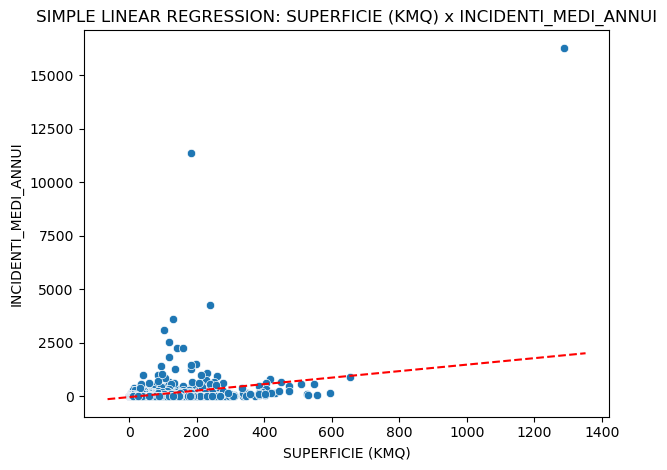

In [435]:
fn.simple_linear_regression(df_accidents_municipality_agg, "SUPERFICIE (KMQ)", "INCIDENTI_MEDI_ANNUI", "model7")

                             OLS Regression Results                             
Dep. Variable:     INCIDENTI_MEDI_ANNUI   R-squared:                       0.919
Model:                              OLS   Adj. R-squared:                  0.919
Method:                   Least Squares   F-statistic:                 9.758e+04
Date:                  Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                          16:11:51   Log-Likelihood:                -48575.
No. Observations:                  8614   AIC:                         9.715e+04
Df Residuals:                      8612   BIC:                         9.717e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.8368      0.745

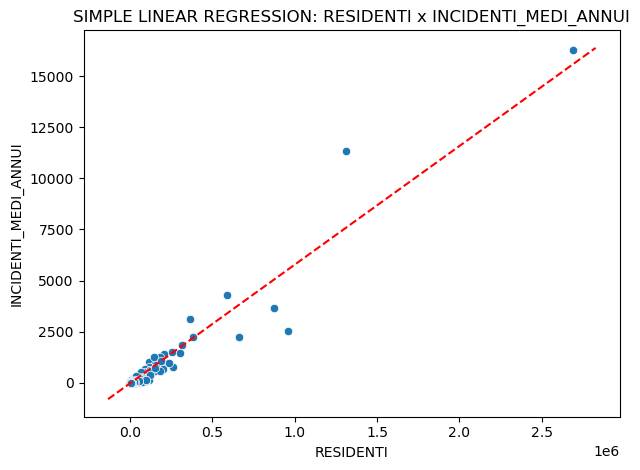

In [436]:
fn.simple_linear_regression(df_accidents_municipality_agg, "RESIDENTI", "INCIDENTI_MEDI_ANNUI", "model3")

## 3.2 Distribuzione del rischio - L'urbanizzazione è associata a una maggiore concentrazione o a un maggiore rischio di incidentalità?

==================================

Nei comuni più urbanizzati il rischio di incidente per abitante è maggiore?

Densità popolazione - Incidenti pro capite (1000) media

R square = 0.014 → La densità della popolazione spiega solo l'1,4% della variabilità degli incidenti pro capite.

Sebbene il coefficiente della regressione risulti statisticamente significativo (p < 0.001), la capacità esplicativa del modello è molto limitata. Ciò suggerisce che la densità abitativa, considerata singolarmente, non rappresenta un buon predittore del rischio di incidentalità pro capite. Pertanto, il livello di urbanizzazione da solo non è sufficiente a spiegare le differenze nel rischio relativo tra i comuni.

==================================

Nei comuni più urbanizzati (più abitanti per kmq) gli incidenti tendono a concentrarsi maggiormente sul territorio?

Densità popolazione - densità incidenti media

R square = 0.583 --> Circa il 58% della variabilità della densità degli incidenti è spiegata dalla densità della popolazione.

L'aumento della densità abitativa è associato a un incremento della densità degli incidenti. La relazione risulta moderatamente forte (R square = 0.583), suggerendo che la concentrazione della popolazione rappresenta un fattore rilevante nella distribuzione spaziale degli incidenti.

Poiché entrambe le variabili sono espresse come densità, il risultato deve essere interpretato con cautela: l'associazione osservata riflette sia una relazione tra urbanizzazione e incidentalità sia il fatto che entrambe le misure sono normalizzate rispetto alla superficie del comune.

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.014
Model:                                          OLS   Adj. R-squared:                  0.013
Method:                               Least Squares   F-statistic:                     117.9
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):           2.74e-27
Time:                                      16:11:52   Log-Likelihood:                -16277.
No. Observations:                              8614   AIC:                         3.256e+04
Df Residuals:                                  8612   BIC:                         3.257e+04
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                          coef    std err          t      P>|t|      [

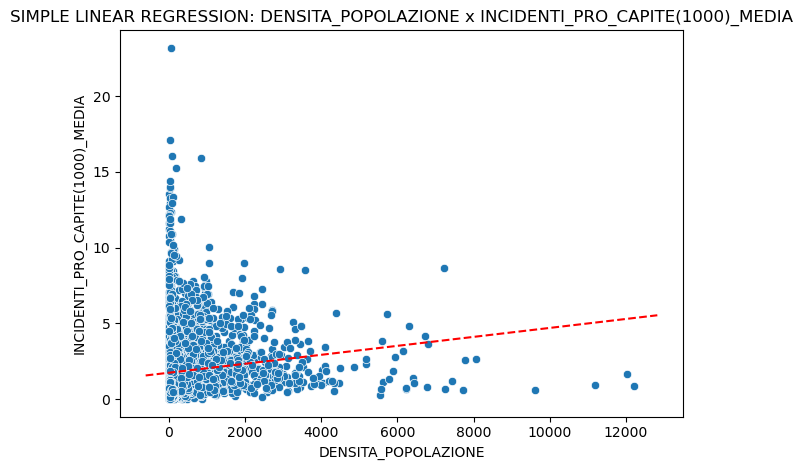

In [437]:
fn.simple_linear_regression(df_accidents_municipality_agg, "DENSITA_POPOLAZIONE", "INCIDENTI_PRO_CAPITE(1000)_MEDIA", "model1")

                               OLS Regression Results                              
Dep. Variable:     DENSITA_INCIDENTI_MEDIA   R-squared:                       0.583
Model:                                 OLS   Adj. R-squared:                  0.583
Method:                      Least Squares   F-statistic:                 1.203e+04
Date:                     Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                             16:11:52   Log-Likelihood:                -13655.
No. Observations:                     8614   AIC:                         2.731e+04
Df Residuals:                         8612   BIC:                         2.733e+04
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

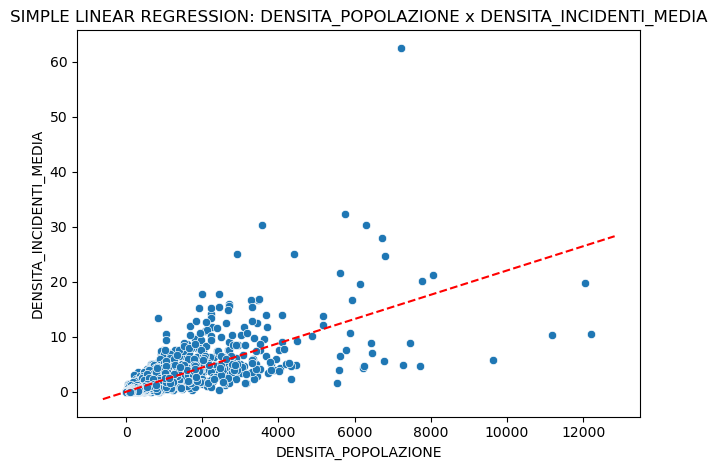

In [438]:
fn.simple_linear_regression(df_accidents_municipality_agg, "DENSITA_POPOLAZIONE", "DENSITA_INCIDENTI_MEDIA", "model2")

## 3.3 Quali caratteristiche del comune spiegano il rischio di incidentalità pro capite?

==================================

Il numero di residenti spiega l' aumentare o meno degli incidenti pro capite?

Residenti - Incidenti pro capite (1000) media

R square = 0.024 → Il numero di residenti spiega solo il 2,4% della variabilità degli incidenti pro capite.

==================================

L' estensione del comune spiega l' aumentare o meno degli incidenti pro capite?

Superficie - Incidenti pro capite (1000) media

R-squared = 0.007 --> La superficie, da sola, non spiega quasi nulla degli incidenti pro capite.

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.024
Model:                                          OLS   Adj. R-squared:                  0.024
Method:                               Least Squares   F-statistic:                     210.6
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):           3.64e-47
Time:                                      16:11:52   Log-Likelihood:                -16231.
No. Observations:                              8614   AIC:                         3.247e+04
Df Residuals:                                  8612   BIC:                         3.248e+04
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

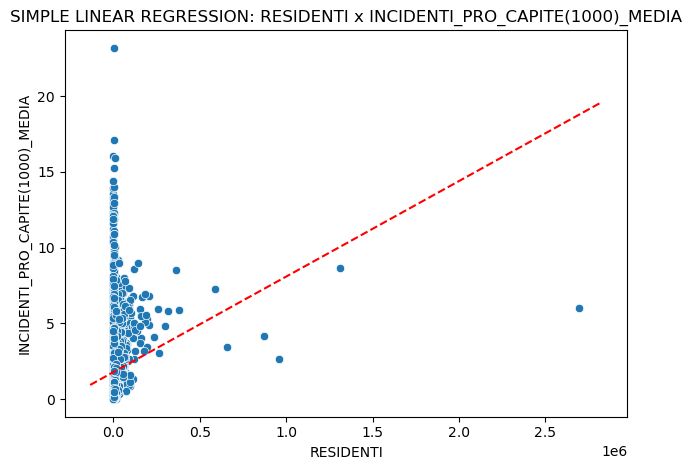

In [439]:
fn.simple_linear_regression(df_accidents_municipality_agg, "RESIDENTI", "INCIDENTI_PRO_CAPITE(1000)_MEDIA", "model4")

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.007
Model:                                          OLS   Adj. R-squared:                  0.007
Method:                               Least Squares   F-statistic:                     58.06
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):           2.82e-14
Time:                                      16:11:52   Log-Likelihood:                -16306.
No. Observations:                              8614   AIC:                         3.262e+04
Df Residuals:                                  8612   BIC:                         3.263e+04
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                       coef    std err          t      P>|t|      [0.0

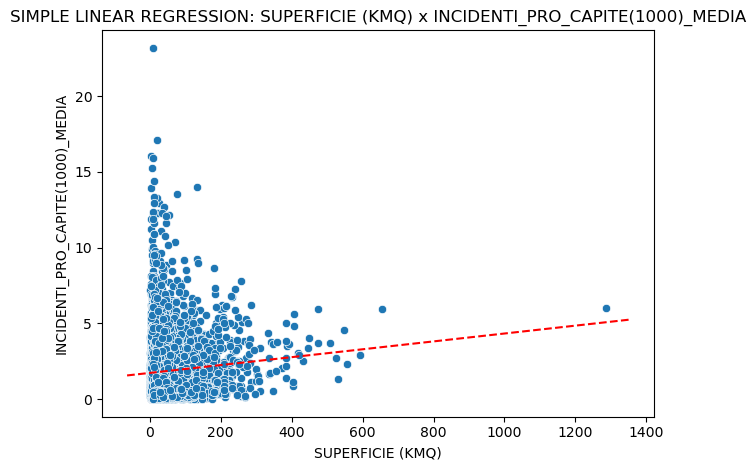

In [440]:
fn.simple_linear_regression(df_accidents_municipality_agg, "SUPERFICIE (KMQ)", "INCIDENTI_PRO_CAPITE(1000)_MEDIA", "model6")

#### RISULTATI DELLE REGRESSIONI LINEARI 

L'analisi delle regressioni lineari semplici evidenzia che il numero di residenti costituisce il principale fattore associato al numero assoluto di incidenti, mentre la superficie del comune presenta una capacità esplicativa decisamente inferiore. Tuttavia, quando l'incidentalità viene espressa come indicatore di rischio (incidenti pro capite), né la popolazione residente né la superficie risultano in grado di spiegare in modo soddisfacente la variabilità osservata. Questo suggerisce che il rischio di incidentalità dipende da una combinazione di fattori e giustifica il ricorso a tecniche di analisi multivariata, come la regressione multipla e il clustering, per ottenere una descrizione più completa del fenomeno.

### Voglio capire se la superficie può spiegare qualcuna delle variabili

==================================

Superficie - Densità di popolazione

R-squared = 0.016 --> Cioè la superficie spiega solo l'1,6% della variabilità della densità di popolazione. Ci si aspetterebbe un R-squared molto alto, visto che la densità è residenti/superficie. Ma essendo formata da due variabili, residenti e superficie appunto, due comuni possono avere la stessa superficie ma numeri di abitanti completamente diversi.

coefficiente negativo

p-value < 0.001

=====================================

Superficie - Densità incidenti

R-squared = 0.001 --> La superficie, da sola, non spiega quasi nulla della densità degli incidenti.



NE RISULTA CHE LA SUPERFICIE NON E' SUFFICIENTEMENTE ESPLICATIVA IN TERMINI DI SPIEGAZIONE DDEI VARI ASPETTI DELL' INCIDENTALITA'

                               OLS Regression Results                              
Dep. Variable:     DENSITA_INCIDENTI_MEDIA   R-squared:                       0.001
Model:                                 OLS   Adj. R-squared:                  0.000
Method:                      Least Squares   F-statistic:                     4.515
Date:                     Tue, 04 Aug 2026   Prob (F-statistic):             0.0336
Time:                             16:11:53   Log-Likelihood:                -17417.
No. Observations:                     8614   AIC:                         3.484e+04
Df Residuals:                         8612   BIC:                         3.485e+04
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

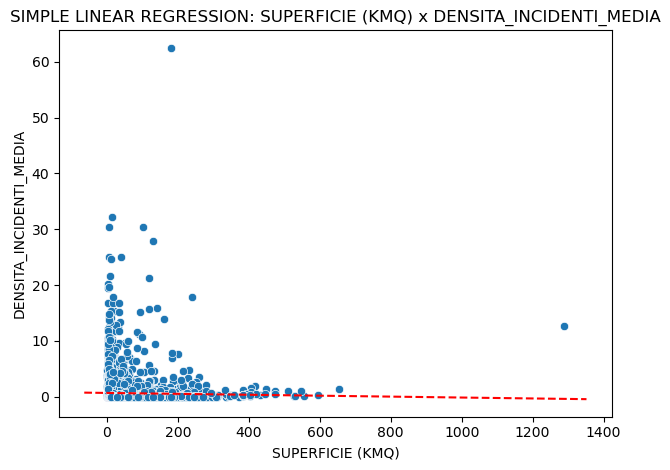

                             OLS Regression Results                            
Dep. Variable:     DENSITA_POPOLAZIONE   R-squared:                       0.016
Model:                             OLS   Adj. R-squared:                  0.016
Method:                  Least Squares   F-statistic:                     138.9
Date:                 Tue, 04 Aug 2026   Prob (F-statistic):           8.27e-32
Time:                         16:11:53   Log-Likelihood:                -67722.
No. Observations:                 8614   AIC:                         1.354e+05
Df Residuals:                     8612   BIC:                         1.355e+05
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              354.5258   

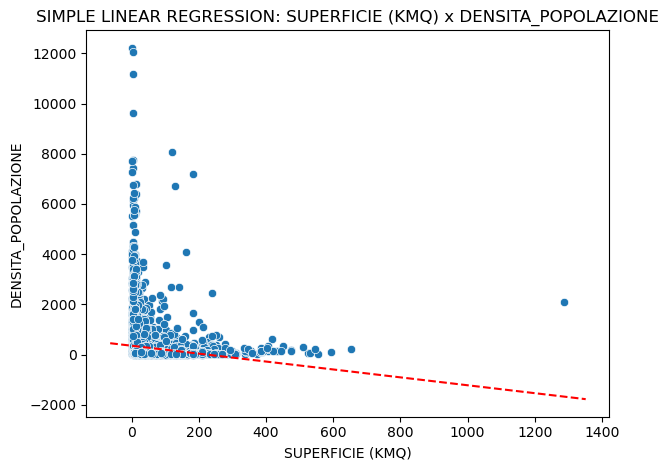

In [441]:
fn.simple_linear_regression(df_accidents_municipality_agg, "SUPERFICIE (KMQ)", "DENSITA_INCIDENTI_MEDIA", "model5")
fn.simple_linear_regression(df_accidents_municipality_agg, "SUPERFICIE (KMQ)", "DENSITA_POPOLAZIONE", "model4")


# REGRESSIONE LINEARE MULTIPLA

## A parità di densità di popolazione, appartenere a una diversa classe demografica o di superficie modifica il rischio di incidenti pro capite?

In [442]:
# import statsmodels.api as sm

# X = df_accidents_municipality_agg[["DENSITA_POPOLAZIONE", c(CLASSE_DEMOGRAFICA), c(CLASSE_SUPERFICIE)]]

# y = df_accidents_municipality_agg["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]
# X = sm.add_constant(X)

# model = sm.OLS(y, X).fit()

# print(model.summary())

In [443]:
# import statsmodels.formula.api as smf

# model = smf.ols(
#     formula="""
#     Q("INCIDENTI_PRO_CAPITE(1000)_MEDIA")
#     ~ DENSITA_POPOLAZIONE
#     + C(CLASSE_DEMOGRAFICA)
#     + C(CLASSE_SUPERFICIE)
#     """,
#     data=df_accidents_municipality_agg
# ).fit()

# print(model.summary())

In [444]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import pandas as pd
# import patsy

# y, X = patsy.dmatrices(
#     """
#     Q("INCIDENTI_PRO_CAPITE(1000)_MEDIA")
#     ~ DENSITA_POPOLAZIONE
#     + C(CLASSE_DEMOGRAFICA)
#     + C(CLASSE_SUPERFICIE)
#     """,
#     data=df_accidents_municipality_agg,
#     return_type="dataframe"
# )

# vif = pd.DataFrame({
#     "Variabile": X.columns,
#     "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# })

# print(vif)

## Quali caratteristiche del comune spiegano il numero medio annuo di incidenti?

In [445]:
import statsmodels.api as sm

# Variabili indipendenti
X = df_accidents_municipality_agg[[
    "RESIDENTI",
    "SUPERFICIE (KMQ)"
]]

# Variabile dipendente
y = df_accidents_municipality_agg["INCIDENTI_MEDI_ANNUI"]

# Aggiunge l'intercetta
X = sm.add_constant(X)

# Modello
model = sm.OLS(y, X).fit()

# Risultati
print(model.summary())

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Variabile"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                             OLS Regression Results                             
Dep. Variable:     INCIDENTI_MEDI_ANNUI   R-squared:                       0.920
Model:                              OLS   Adj. R-squared:                  0.920
Method:                   Least Squares   F-statistic:                 4.974e+04
Date:                  Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                          16:11:53   Log-Likelihood:                -48498.
No. Observations:                  8614   AIC:                         9.700e+04
Df Residuals:                      8611   BIC:                         9.702e+04
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -

### Regressione lineare multipla: effetto di residenti e superficie sugli incidenti medi annui

Per approfondire l'analisi svolta con le regressioni lineari semplici, è stato stimato un modello di regressione lineare multipla utilizzando come variabile dipendente il numero medio annuo di incidenti (`INCIDENTI_MEDI_ANNUI`) e come variabili esplicative il numero di residenti (`RESIDENTI`) e la superficie comunale (`SUPERFICIE (KMQ)`).

L'obiettivo dell'analisi è verificare se entrambe le variabili contribuiscono a spiegare il numero medio di incidenti quando vengono considerate simultaneamente.

#### Risultati

Il modello risulta altamente significativo dal punto di vista statistico (F = 49 774; p < 0.001) e presenta un coefficiente di determinazione pari a **R² = 0.920** (Adjusted R² = 0.920). Ciò indica che il 92% della variabilità del numero medio annuo di incidenti è spiegato congiuntamente dalle due variabili considerate.

Entrambi i coefficienti di regressione risultano statisticamente significativi (p < 0.001):

- **RESIDENTI** presenta un coefficiente positivo (β = 0.0059), indicando che, a parità di superficie, un aumento della popolazione residente è associato a un incremento del numero medio annuo di incidenti.
- **SUPERFICIE (KMQ)** presenta invece un coefficiente negativo (β = -0.1916), suggerendo che, a parità di popolazione residente, i comuni più estesi tendono a registrare un numero medio di incidenti inferiore.

Questo risultato evidenzia come l'effetto della superficie emerga solamente quando viene controllata la dimensione demografica del comune, fornendo un'informazione aggiuntiva rispetto alle regressioni lineari semplici.

#### Verifica della multicollinearità

Per valutare l'eventuale presenza di multicollinearità tra le variabili esplicative è stato calcolato il **Variance Inflation Factor (VIF)**.

I valori ottenuti sono:


- RESIDENTI | 1.17 (VIF)

- SUPERFICIE (KMQ) | 1.17 (VIF)

Entrambi i valori risultano ampiamente inferiori alla soglia comunemente utilizzata (VIF < 5), indicando l'assenza di problemi di multicollinearità e confermando che i coefficienti stimati possono essere interpretati in modo affidabile.

#### Conclusioni

La regressione lineare multipla conferma che il numero di residenti rappresenta il principale fattore associato al numero medio di incidenti. Inoltre, una volta controllato l'effetto della popolazione, emerge che la superficie del comune fornisce un contributo esplicativo aggiuntivo, suggerendo che comuni territorialmente più estesi tendano a presentare, a parità di residenti, un numero medio di incidenti inferiore. Nel complesso, il modello mostra un'elevata capacità esplicativa e costituisce un valido strumento per descrivere il fenomeno a livello comunale.

In [446]:
# Gli aggiungo la densità della popolazione dato che aiuta a spiegare gli incidenti in termini assoluti come si era visto nella reg lineare semplice

# Variabili indipendenti
X = df_accidents_municipality_agg[[
    "RESIDENTI",
    "SUPERFICIE (KMQ)",
    "DENSITA_POPOLAZIONE"
]]

# Variabile dipendente
y = df_accidents_municipality_agg["INCIDENTI_MEDI_ANNUI"]

# Aggiunge l'intercetta
X = sm.add_constant(X)

# Modello
model = sm.OLS(y, X).fit()

# Risultati
print(model.summary())

vif = pd.DataFrame()
vif["Variabile"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                             OLS Regression Results                             
Dep. Variable:     INCIDENTI_MEDI_ANNUI   R-squared:                       0.926
Model:                              OLS   Adj. R-squared:                  0.926
Method:                   Least Squares   F-statistic:                 3.597e+04
Date:                  Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                          16:11:53   Log-Likelihood:                -48174.
No. Observations:                  8614   AIC:                         9.636e+04
Df Residuals:                      8610   BIC:                         9.638e+04
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

L'aggiunta della densità di popolazione rispetto al modello precedente determina un lieve incremento della capacità esplicativa del modello (R² da 0.920 a 0.926), suggerendo che il grado di urbanizzazione fornisce un'informazione complementare rispetto al numero di residenti e alla superficie comunale. Tuttavia, l'incremento è contenuto (0,6 punti percentuali), indicando che la maggior parte della variabilità del numero di incidenti è già spiegata dalla popolazione residente.

In [447]:
import statsmodels.api as sm
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================================
# VARIABILI INDIPENDENTI
# ==========================================================

X = pd.concat(
    [
        df_accidents_municipality_agg[["DENSITA_POPOLAZIONE"]],
        pd.get_dummies(
            df_accidents_municipality_agg[
                ["CLASSE_DEMOGRAFICA", "CLASSE_SUPERFICIE"]
            ],
            drop_first=True
        )
    ],
    axis=1
)

# Trasforma tutte le colonne in float
X = X.astype(float)

# ==========================================================
# VARIABILE DIPENDENTE
# ==========================================================

y = df_accidents_municipality_agg["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

# ==========================================================
# AGGIUNTA INTERCETTA
# ==========================================================

X = sm.add_constant(X)

# ==========================================================
# MODELLO
# ==========================================================

model = sm.OLS(y, X).fit()

print(model.summary())

# ==========================================================
# MULTICOLLINEARITÀ
# ==========================================================

vif = pd.DataFrame()

vif["Variabile"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.081
Model:                                          OLS   Adj. R-squared:                  0.081
Method:                               Least Squares   F-statistic:                     95.38
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):          1.26e-152
Time:                                      16:11:53   Log-Likelihood:                -15969.
No. Observations:                              8614   AIC:                         3.196e+04
Df Residuals:                                  8605   BIC:                         3.202e+04
Df Model:                                         8                                         
Covariance Type:                          nonrobust                                         
                                       coef    std err          t     

### Conclusioni

Per analizzare il rischio di incidentalità è stato stimato un modello di regressione lineare multipla utilizzando come variabile dipendente il numero medio di incidenti pro capite e come predittori la densità di popolazione, la classe demografica e la classe di superficie del comune.

Il modello risulta statisticamente significativo (F = 95.38; p < 0.001), indicando che almeno una delle variabili considerate contribuisce in modo significativo alla spiegazione del fenomeno. Tuttavia, il coefficiente di determinazione risulta pari a **R² = 0.081**, evidenziando come il modello sia in grado di spiegare soltanto l'8,1% della variabilità osservata.

Tra le variabili considerate, la **classe demografica** risulta quella maggiormente associata al rischio di incidentalità, mentre solo alcune categorie della **classe di superficie** mostrano coefficienti statisticamente significativi. Anche la **densità di popolazione** risulta significativa, suggerendo che il grado di urbanizzazione fornisca un contributo informativo aggiuntivo rispetto alle sole caratteristiche dimensionali del comune.

Il confronto con il modello costruito utilizzando esclusivamente **residenti** e **superficie** come variabili continue mostra un miglioramento della capacità esplicativa (R² = 0.081 contro R² = 0.025). Questo risultato suggerisce che la rappresentazione del territorio mediante classi omogenee descrive il rischio di incidentalità in modo più efficace rispetto all'utilizzo dei soli valori assoluti.

L'analisi della multicollinearità, effettuata mediante il **Variance Inflation Factor (VIF)**, non ha evidenziato criticità rilevanti: tutti i valori risultano inferiori alle soglie comunemente adottate in letteratura, consentendo un'interpretazione affidabile dei coefficienti stimati.

Nel complesso, i risultati mostrano che le sole caratteristiche demografiche e territoriali del comune non sono sufficienti a spiegare il rischio di incidentalità. Sebbene alcune variabili risultino statisticamente significative, la ridotta capacità esplicativa del modello suggerisce che il fenomeno dipenda anche da fattori non disponibili nel dataset, quali caratteristiche della rete stradale, intensità del traffico, mobilità pendolare, infrastrutture e altri elementi territoriali. Per questo motivo, nelle sezioni successive l'analisi viene approfondita mediante tecniche inferenziali (ANOVA) e di clustering, con l'obiettivo di individuare differenze tra gruppi di comuni e profili territoriali omogenei.

In [448]:
import statsmodels.api as sm
import pandas as pd

X1 = pd.get_dummies(
    df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"],
    drop_first=True
).astype(float)

X1 = sm.add_constant(X1)

y = df_accidents_municipality_agg["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

model1 = sm.OLS(y, X1).fit()

print(model1.summary())

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.080
Model:                                          OLS   Adj. R-squared:                  0.079
Method:                               Least Squares   F-statistic:                     248.9
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):          6.69e-155
Time:                                      16:11:53   Log-Likelihood:                -15977.
No. Observations:                              8614   AIC:                         3.196e+04
Df Residuals:                                  8610   BIC:                         3.199e+04
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                    coef    std err          t      P>|t|      [0.025 

In [449]:
X2 = pd.concat(
    [
        pd.get_dummies(
            df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"],
            drop_first=True
        ),
        pd.get_dummies(
            df_accidents_municipality_agg["CLASSE_SUPERFICIE"],
            drop_first=True
        )
    ],
    axis=1
).astype(float)

X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()

print(model2.summary())

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.081
Model:                                          OLS   Adj. R-squared:                  0.080
Method:                               Least Squares   F-statistic:                     107.7
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):          8.05e-152
Time:                                      16:11:53   Log-Likelihood:                -15974.
No. Observations:                              8614   AIC:                         3.196e+04
Df Residuals:                                  8606   BIC:                         3.202e+04
Df Model:                                         7                                         
Covariance Type:                          nonrobust                                         
                    coef    std err          t      P>|t|      [0.025 

In [450]:
X3 = pd.concat(
    [
        df_accidents_municipality_agg[["DENSITA_POPOLAZIONE"]],
        pd.get_dummies(
            df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"],
            drop_first=True
        ),
        pd.get_dummies(
            df_accidents_municipality_agg["CLASSE_SUPERFICIE"],
            drop_first=True
        )
    ],
    axis=1
).astype(float)

X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()

print(model3.summary())

                                   OLS Regression Results                                   
Dep. Variable:     INCIDENTI_PRO_CAPITE(1000)_MEDIA   R-squared:                       0.081
Model:                                          OLS   Adj. R-squared:                  0.081
Method:                               Least Squares   F-statistic:                     95.38
Date:                              Tue, 04 Aug 2026   Prob (F-statistic):          1.26e-152
Time:                                      16:11:53   Log-Likelihood:                -15969.
No. Observations:                              8614   AIC:                         3.196e+04
Df Residuals:                                  8605   BIC:                         3.202e+04
Df Model:                                         8                                         
Covariance Type:                          nonrobust                                         
                          coef    std err          t      P>|t|      [

In [451]:
comparison = pd.DataFrame({
    "Modello": [
        "Classe demografica",
        "Classe demografica + Classe superficie",
        "Modello completo"
    ],
    "R²": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared
    ],
    "Adj. R²": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj
    ],
    "AIC": [
        model1.aic,
        model2.aic,
        model3.aic
    ],
    "BIC": [
        model1.bic,
        model2.bic,
        model3.bic
    ]
})

display(comparison)

,Modello,R²,Adj. R²,AIC,BIC
0,Classe demografica,0.079804,0.079484,31962.420134,31990.664711
1,Classe demografica + Classe superficie,0.080543,0.079796,31963.496818,32019.985971
2,Modello completo,0.081454,0.080600,31956.958825,32020.509121


# ANOVA

## 1 - I comportamenti dei comuni (sulla base delle classi demografiche) differiscono tra di loro a livello di incidenti pro capite?

Vorrei capire se le città grandi o piccole (in base alla classe demografica) abbiano comportamenti differenti rispetto a incidenti pro capite utilizzando ANOVA

Ipotesi nulla (H0) = La media del tasso di incidenti per 1000 abitanti è uguale in tutte le classi demografiche.

Ipotesi alternativa (H1) = Almeno una classe demografica presenta una media diversa.

In [452]:
molto_piccolo = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"] == "Molto piccolo"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

piccolo = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"] == "Piccolo"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

medio = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"] == "Medio"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

grande = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"] == "Grande"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

In [453]:
#ANOVA
f = stats.f_oneway(molto_piccolo,piccolo,medio,grande)

print(f'F-statistic: {f.statistic}')
print(f'P-value [%]: {f.pvalue*100:.10f}')

alpha = 0.05

if f.pvalue <= alpha:
    print("p-value <= alpha | risultato statisticamente significativo | H0 rifiutata")
else:
    print("p-value > alpha | risultato non statisticamente significativo | non si rifiuta H0")

# F-statistic = 248.9 è molto alta: significa che la variabilità tra i gruppi è molto maggiore della variabilità dentro i gruppi.
# P-value [%] = 0.00.. indica che la probabilità di ottenere un risultato così estremo se l’ipotesi nulla fosse vera è trascurabile.
# Quindi H0 viene rifiutata: le medie non sono tutte uguali

F-statistic: 248.9013873861594
P-value [%]: 0.0000000000
p-value <= alpha | risultato statisticamente significativo | H0 rifiutata


In [454]:
#T-TEST
# Dopo aver verificato con ANOVA l'esistenza di differenze
# tra le classi demografiche, confrontiamo direttamente
# i comuni grandi e molto piccoli tramite t-test.
t_stat, p_value = stats.ttest_ind(grande, molto_piccolo)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

alpha = 0.05

if p_value <= alpha:
    print("p-value <= alpha | risultato statisticamente significativo | H0 rifiutata")
else:
    print("p-value > alpha | risultato non statisticamente significativo | non si rifiuta H0")

T-statistic: 18.544123887825833
P-value: 2.963693360214927e-72
p-value <= alpha | risultato statisticamente significativo | H0 rifiutata


L'ANOVA a una via ha evidenziato differenze statisticamente significative tra le medie delle classi demografiche (F = 248.90, p < 0.001), indicando che almeno una classe presenta una media differente rispetto alle altre. Per individuare una specifica differenza, è stato successivamente eseguito un t-test tra i comuni "Grande" e "Molto piccolo". Anche questo test ha restituito un risultato statisticamente significativo (t = 18.54, p < 0.001), confermando che le medie dei due gruppi sono significativamente diverse.

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       Grande         Medio  -1.2294    0.0 -1.4234 -1.0354   True
       Grande Molto piccolo  -1.7688    0.0 -1.9617 -1.5758   True
       Grande       Piccolo  -1.7772    0.0 -1.9608 -1.5936   True
        Medio Molto piccolo  -0.5394    0.0 -0.6634 -0.4153   True
        Medio       Piccolo  -0.5478    0.0 -0.6567 -0.4389   True
Molto piccolo       Piccolo  -0.0084 0.9971 -0.1155  0.0987  False
------------------------------------------------------------------


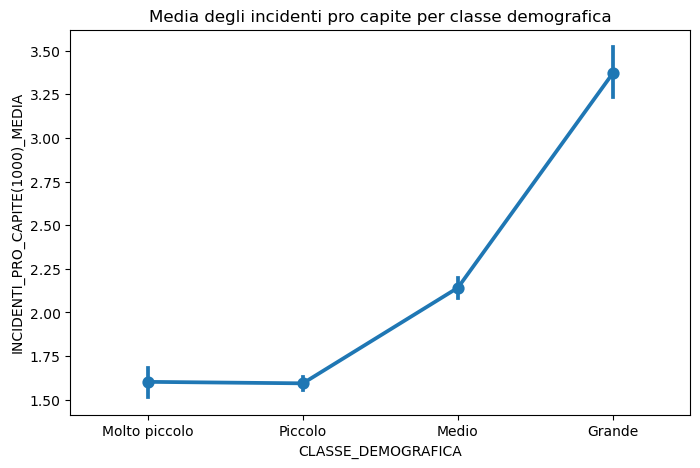

In [455]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_accidents_municipality_agg["INCIDENTI_PRO_CAPITE(1000)_MEDIA"],
    groups=df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"],
    alpha=0.05
)


print(tukey)

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_accidents_municipality_agg,
    x="CLASSE_DEMOGRAFICA",
    y="INCIDENTI_PRO_CAPITE(1000)_MEDIA",
    order=["Molto piccolo", "Piccolo", "Medio", "Grande"],
    errorbar=("ci", 95) #È l'intervallo di confidenza al 95% della media-->saranno le barrette
)

plt.title("Media degli incidenti pro capite per classe demografica")
plt.show()

#Ogni punto rappresenta la media degli incidenti pro capite della classe demografica.

In [456]:
#INVERTO I RISULTATI PERCHE' IL TEST DI TUKEY FA GRUPPO2-GRUPPO1 E SE VIENE FATTO ES PICCOLO-GRANDE VIENE NEGATIVO

tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

tukey_df["meandiff"] = -tukey_df["meandiff"]

tukey_df[["group1", "group2"]] = tukey_df[["group2", "group1"]]

In [457]:
tukey_df.sort_values("meandiff",ascending=False)

,group1,group2,meandiff,p-adj,lower,upper,reject
2,Piccolo,Grande,1.7772,0.0000,-1.9608,-1.5936,True
1,Molto piccolo,Grande,1.7688,0.0000,-1.9617,-1.5758,True
0,Medio,Grande,1.2294,0.0000,-1.4234,-1.0354,True
4,Piccolo,Medio,0.5478,0.0000,-0.6567,-0.4389,True
3,Molto piccolo,Medio,0.5394,0.0000,-0.6634,-0.4153,True
5,Piccolo,Molto piccolo,0.0084,0.9971,-0.1155,0.0987,False


In [458]:
df_accidents_municipality_agg.groupby("CLASSE_DEMOGRAFICA")[
    "INCIDENTI_PRO_CAPITE(1000)_MEDIA"
].describe()

,count,mean,std,min,25%,50%,75%,max
CLASSE_DEMOGRAFICA,,,,,,,,
Grande,531.0,3.370938,1.698713,0.334109,2.130829,3.154340,4.440452,9.207852
Medio,2000.0,2.141538,1.319726,0.006462,1.216321,1.980138,2.809101,15.896264
Molto piccolo,2106.0,1.602181,2.025555,0.000000,0.457587,0.945671,1.927996,23.194112
Piccolo,3977.0,1.593741,1.321980,0.000000,0.675970,1.304643,2.146546,15.234613


### Conclusioni

L'ANOVA a una via ha evidenziato differenze statisticamente significative tra le medie degli incidenti pro capite nelle diverse classi demografiche (F = 248.90; p < 0.001), consentendo di rifiutare l'ipotesi nulla secondo cui tutte le classi presentano lo stesso livello medio di incidentalità.

Per individuare quali gruppi differissero tra loro è stato successivamente applicato il test post-hoc di Tukey. I risultati mostrano che quasi tutti i confronti tra le classi risultano statisticamente significativi, ad eccezione del confronto tra i comuni **Piccoli** e **Molto piccoli**, che presentano livelli medi di incidentalità statisticamente indistinguibili.

L'analisi descrittiva conferma inoltre un andamento crescente del numero medio di incidenti pro capite all'aumentare della classe demografica:

- Grande             | 3.37 incidenti pro capite medi (1000)
- Medio              | 2.14 incidenti pro capite medi (1000)
- Molto piccolo      | 1.60 incidenti pro capite medi (1000)
- Piccolo            | 1.59 incidenti pro capite medi (1000)

I comuni appartenenti alla classe **Grande** registrano quindi il valore medio più elevato, seguiti dai comuni **Medi**, mentre le classi **Piccolo** e **Molto piccolo** mostrano livelli di incidentalità molto simili.

Questi risultati sono coerenti con quanto osservato nella regressione lineare multipla, nella quale la **classe demografica** è risultata la variabile maggiormente associata al rischio di incidentalità. Tuttavia, la regressione ha evidenziato anche una capacità esplicativa complessivamente limitata (R² = 0.081), suggerendo che la dimensione demografica del comune, pur essendo statisticamente significativa, non è sufficiente da sola a spiegare il fenomeno.

Per verificare se anche l'estensione territoriale del comune sia associata a differenti livelli di rischio, nella sezione successiva viene applicata la medesima procedura utilizzando come fattore di raggruppamento la **classe di superficie**, così da valutare se comuni appartenenti a differenti classi dimensionali presentino differenze statisticamente significative nel numero medio di incidenti pro capite.

## 2 - I comportamenti dei comuni (sulla base delle classi di superficie) differiscono tra di loro a livello di incidenti pro capite?

Vorrei capire se le città grandi o piccole (in base alla classe di superficie) abbiano comportamenti differenti rispetto a incidenti pro capite utilizzando ANOVA

Ipotesi nulla (H0) = La media del tasso di incidenti per 1000 abitanti è uguale in tutte le classi di superficie.

Ipotesi alternativa (H1) = Almeno una classe di superficie presenta una media diversa.

In [459]:
molto_piccolo = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_SUPERFICIE"] == "Molto piccolo"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

piccolo = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_SUPERFICIE"] == "Piccolo"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

medio = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_SUPERFICIE"] == "Medio"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

grande = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_SUPERFICIE"] == "Grande"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

molto_grande = df_accidents_municipality_agg[df_accidents_municipality_agg["CLASSE_SUPERFICIE"] == "Molto grande"]["INCIDENTI_PRO_CAPITE(1000)_MEDIA"]

In [460]:
#ANOVA
f = stats.f_oneway(molto_piccolo,piccolo,medio,grande, molto_grande)

print(f'F-statistic: {f.statistic}')
print(f'P-value [%]: {f.pvalue*100:.10f}')

alpha = 0.05

if f.pvalue <= alpha:
    print("p-value <= alpha | risultato statisticamente significativo | H0 rifiutata")
else:
    print("p-value > alpha | risultato non statisticamente significativo | non si rifiuta H0")

# F-statistic = 248.9 è molto alta: significa che la variabilità tra i gruppi è molto maggiore della variabilità dentro i gruppi.
# P-value [%] = 0.00.. indica che la probabilità di ottenere un risultato così estremo se l’ipotesi nulla fosse vera è trascurabile.
# Quindi H0 viene rifiutata: le medie non sono tutte uguali

F-statistic: 13.168996729517216
P-value [%]: 0.0000000107
p-value <= alpha | risultato statisticamente significativo | H0 rifiutata


L'ANOVA applicata alle classi di superficie evidenzia differenze statisticamente significative tra le medie degli incidenti pro capite (F = 13.17; p < 0.001), consentendo di rifiutare l'ipotesi nulla secondo cui tutte le classi presentano lo stesso livello medio di incidentalità.

Rispetto all'analisi condotta sulle classi demografiche, l'F-statistic risulta tuttavia sensibilmente inferiore, indicando che la variabilità spiegata dalla classe di superficie è più contenuta. Ciò suggerisce che l'estensione territoriale del comune è associata al rischio di incidentalità, ma il suo contributo risulta meno rilevante rispetto alla dimensione demografica.

Per individuare quali classi di superficie differiscono tra loro verrà applicato il test post-hoc di Tukey, che consentirà di identificare le coppie di gruppi con differenze statisticamente significative.

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       Grande         Medio  -0.2568 0.0131 -0.4776  -0.036   True
       Grande  Molto grande   0.6579 0.0075  0.1203  1.1955   True
       Grande Molto piccolo  -0.3834    0.0 -0.5912 -0.1757   True
       Grande       Piccolo  -0.3098 0.0001 -0.5006 -0.1189   True
        Medio  Molto grande   0.9147    0.0  0.3925  1.4368   True
        Medio Molto piccolo  -0.1267 0.2158 -0.2904  0.0371  False
        Medio       Piccolo   -0.053 0.8464 -0.1947  0.0888  False
 Molto grande Molto piccolo  -1.0413    0.0 -1.5581 -0.5245   True
 Molto grande       Piccolo  -0.9676    0.0 -1.4779 -0.4574   True
Molto piccolo       Piccolo   0.0737 0.4533 -0.0468  0.1941  False
------------------------------------------------------------------


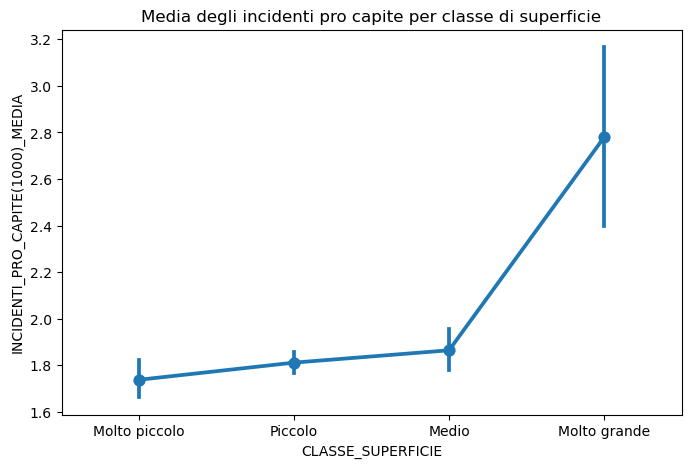

In [461]:
tukey = pairwise_tukeyhsd(
    endog=df_accidents_municipality_agg["INCIDENTI_PRO_CAPITE(1000)_MEDIA"],
    groups=df_accidents_municipality_agg["CLASSE_SUPERFICIE"],
    alpha=0.05
)


print(tukey)

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_accidents_municipality_agg,
    x="CLASSE_SUPERFICIE",
    y="INCIDENTI_PRO_CAPITE(1000)_MEDIA",
    order=["Molto piccolo", "Piccolo", "Medio","Molto grande"],
    errorbar=("ci", 95) #È l'intervallo di confidenza al 95% della media-->saranno le barrette
)

plt.title("Media degli incidenti pro capite per classe di superficie")
plt.show()

#Ogni punto rappresenta la media degli incidenti pro capite della classe di superficie.

### Conclusioni

L'ANOVA applicata alle classi di superficie ha evidenziato differenze statisticamente significative tra le medie degli incidenti pro capite (F = 13.17; p < 0.001), consentendo di rifiutare l'ipotesi nulla secondo cui tutte le classi presentano lo stesso livello medio di incidentalità.

Per individuare le specifiche differenze tra i gruppi è stato applicato il test post-hoc di Tukey. I risultati mostrano che le differenze significative riguardano principalmente i comuni appartenenti alle classi **Grande** e **Molto grande**, mentre le classi **Medio**, **Piccolo** e **Molto piccolo** non presentano differenze statisticamente significative tra loro.

Rispetto all'analisi svolta sulle classi demografiche, la classe di superficie mostra quindi una minore capacità di discriminare i livelli di rischio di incidentalità. Questo risultato è coerente con quanto emerso nella regressione lineare multipla, nella quale la classe di superficie forniva un contributo esplicativo limitato rispetto alla classe demografica.

Nel complesso, le analisi inferenziali confermano che la dimensione demografica del comune rappresenta la caratteristica maggiormente associata al rischio di incidentalità, mentre la sola estensione territoriale risulta meno determinante. Nella sezione successiva verrà applicata una tecnica di clustering con l'obiettivo di individuare gruppi omogenei di comuni sulla base dei principali indicatori di incidentalità, senza imporre una classificazione a priori.

# CLUSTERING

## 1 - **RISCHIO PURO** Esistono gruppi di comuni che presentano caratteristiche simili in termini di rischio di incidentalità, indipendentemente dalla loro dimensione demografica o territoriale?

2 variabili:

INCIDENTI PRO CAPITE --> così da tener conto degli incidenti normalizzati e non assoluti

DENSITA' INCIDENTI-->che tiene coto di quanti incidenti ci siano stati in base alla superficie

CLUSTERING utilizzando K_MEANS per individuare il **RISCHIO PURO**

In [462]:
df_accidents_municipality_agg[["INCIDENTI_PRO_CAPITE(1000)_MEDIA","DENSITA_INCIDENTI_MEDIA","LOG_RESIDENTI"]].corr()

,INCIDENTI_PRO_CAPITE(1000)_MEDIA,DENSITA_INCIDENTI_MEDIA,LOG_RESIDENTI
INCIDENTI_PRO_CAPITE(1000)_MEDIA,1.000000,0.348228,0.236478
DENSITA_INCIDENTI_MEDIA,0.348228,1.000000,0.456516
LOG_RESIDENTI,0.236478,0.456516,1.000000


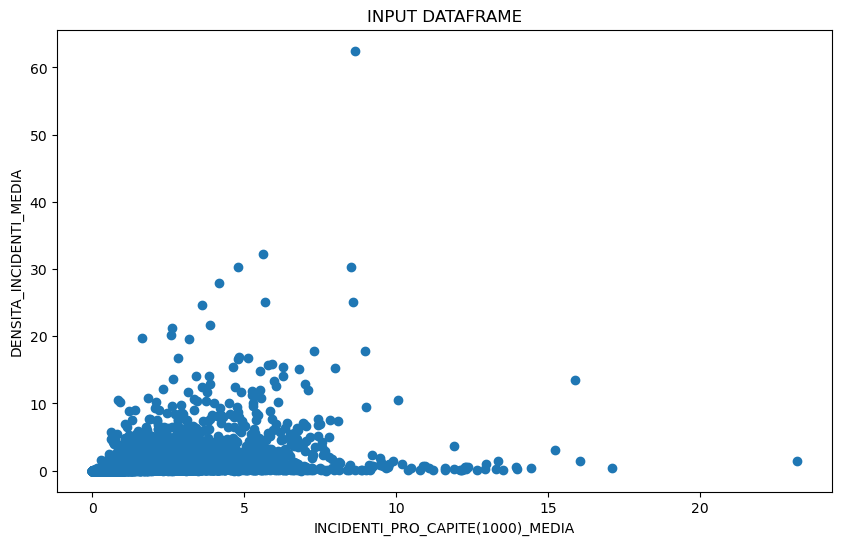

In [463]:
# K-MEANS - SEGMENTAZIONE DEI COMUNI IN BASE AL RISCHIO
# Preparazione dei dati
input_dataframe = df_accidents_municipality_agg[["INCIDENTI_PRO_CAPITE(1000)_MEDIA","DENSITA_INCIDENTI_MEDIA"]]

plt.figure(figsize=(10, 6))
plt.scatter(input_dataframe["INCIDENTI_PRO_CAPITE(1000)_MEDIA"], input_dataframe["DENSITA_INCIDENTI_MEDIA"], marker="o")
plt.title('INPUT DATAFRAME')
plt.xlabel('INCIDENTI_PRO_CAPITE(1000)_MEDIA')
plt.ylabel('DENSITA_INCIDENTI_MEDIA')

plt.show()

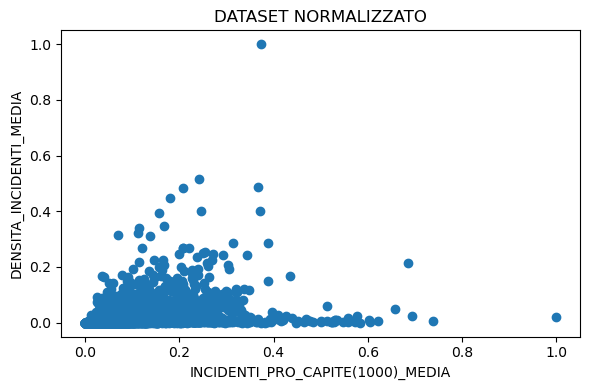

In [464]:
scaler = MinMaxScaler()

scaled_dataframe = pd.DataFrame(scaler.fit_transform(input_dataframe),
                                columns=input_dataframe.columns)

# Visualizzazione del dataset normalizzato
plt.figure(figsize=(6, 4))

plt.scatter(scaled_dataframe["INCIDENTI_PRO_CAPITE(1000)_MEDIA"],
            scaled_dataframe["DENSITA_INCIDENTI_MEDIA"],
            marker="o")

plt.title("DATASET NORMALIZZATO")
plt.xlabel("INCIDENTI_PRO_CAPITE(1000)_MEDIA")
plt.ylabel("DENSITA_INCIDENTI_MEDIA")

plt.tight_layout()

plt.show()

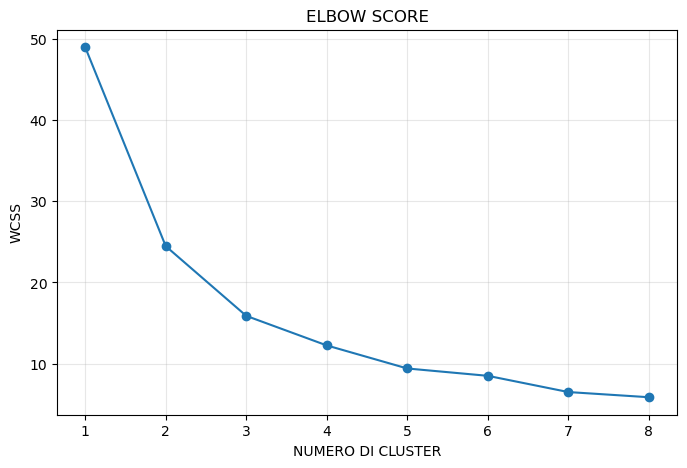

In [465]:
# Metodo del gomito-Elbow score
k_values = range(1, 9)
wcss = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_dataframe)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss,marker="o")
plt.title("ELBOW SCORE")
plt.xlabel("NUMERO DI CLUSTER")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

k = 2 -> Silhouette Score = 0.612
k = 3 -> Silhouette Score = 0.557
k = 4 -> Silhouette Score = 0.530
k = 5 -> Silhouette Score = 0.533
k = 6 -> Silhouette Score = 0.531
k = 7 -> Silhouette Score = 0.501
k = 8 -> Silhouette Score = 0.506


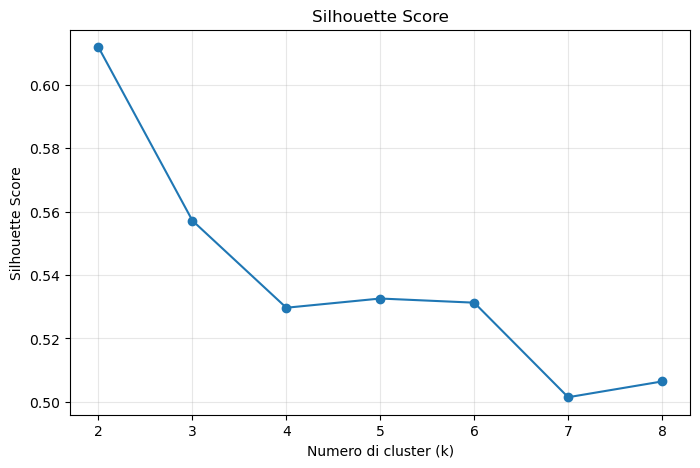

In [466]:
#Metodo Silhouette per trovare il numero di cluster migliore 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)
scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_dataframe.drop(columns="CLUSTER", errors="ignore"))

    score = silhouette_score(
        scaled_dataframe.drop(columns="CLUSTER", errors="ignore"),
        labels
    )

    scores.append(score)
    print(f"k = {k} -> Silhouette Score = {score:.3f}")



plt.figure(figsize=(8,5))

plt.plot(k_values, scores, marker="o")

plt.title("Silhouette Score")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

# Il Silhouette Score misura quanto i cluster sono:

# compatti (i punti dello stesso cluster sono vicini);
# separati (i cluster sono ben distinti).

# Più è vicino a 1, meglio è. In questo caso il migliore sembrerebbe k=2

Il metodo del gomito e il Silhouette Score sono stati utilizzati per valutare il numero ottimale di cluster. Sebbene il Silhouette Score raggiunga il valore massimo per k=2, è stata scelta una soluzione con k=4, in quanto consente una segmentazione più dettagliata e interpretabile dei comuni, distinguendo differenti livelli di incidentalità anziché una semplice suddivisione in due gruppi.

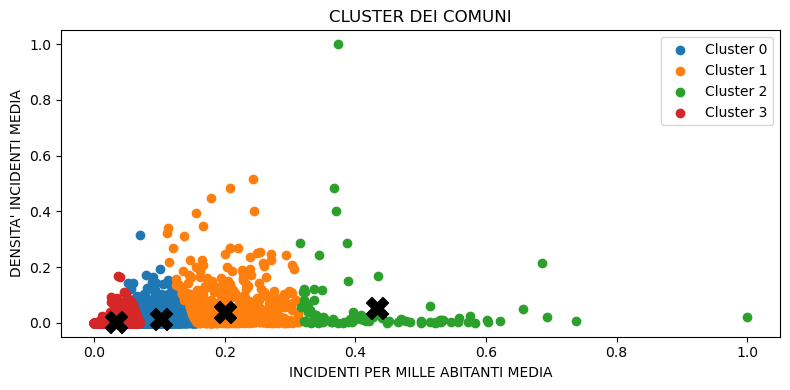

In [467]:
# MODELLO K-MEANS

# Inizializzazione e addestramento del modello
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans.fit(scaled_dataframe)

# Assegnazione dei cluster al DataFrame normalizzato
scaled_dataframe["CLUSTER"] = kmeans.labels_
# Copia dei cluster nel DataFrame originale
df_accidents_municipality_agg["CLUSTER"] = scaled_dataframe["CLUSTER"]


# VISUALIZZAZIONE DEI CLUSTER
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("CLUSTER")

plt.figure(figsize=(8,4))

for cluster, data in clusters:

    plt.scatter(data["INCIDENTI_PRO_CAPITE(1000)_MEDIA"],data["DENSITA_INCIDENTI_MEDIA"],
                label=f"Cluster {cluster}")

    plt.scatter(centroids[cluster, 0],centroids[cluster, 1],marker="X",color="black",
                s=250)

plt.xlabel("INCIDENTI PER MILLE ABITANTI MEDIA")
plt.ylabel("DENSITA' INCIDENTI MEDIA")
plt.title("CLUSTER DEI COMUNI")
plt.legend()

plt.tight_layout()

plt.show()

In [468]:
summary = (
    df_accidents_municipality_agg
    .groupby("CLUSTER")
    .agg(
        NUM_COMUNI=("COMUNE","count"),
        INCIDENTI_PRO_CAPITE=("INCIDENTI_PRO_CAPITE(1000)_MEDIA","mean"),
        DENSITA_INCIDENTI=("DENSITA_INCIDENTI_MEDIA","mean")
    )
    .round(2)
)

display(summary)

,NUM_COMUNI,INCIDENTI_PRO_CAPITE,DENSITA_INCIDENTI
CLUSTER,,,
0,3013,2.36,0.78
1,871,4.64,2.43
2,95,10.05,3.28
3,4635,0.79,0.19


In [469]:
composition_prct = (
    pd.crosstab(
        df_accidents_municipality_agg["CLUSTER"],
        df_accidents_municipality_agg["CLASSE_DEMOGRAFICA"],
        normalize="index"
    ) * 100
).round(1)

display(composition_prct)

CLASSE_DEMOGRAFICA,Grande,Medio,Molto piccolo,Piccolo
CLUSTER,,,,
0,7.4,34.2,14.7,43.8
1,26.4,28.1,17.6,27.9
2,13.7,7.4,54.7,24.2
3,1.4,15.5,31.5,51.6


In [470]:
df_accidents_municipality_agg["CLUSTER"]=df_accidents_municipality_agg["CLUSTER"].replace({3: "Bassa incidentalità",
                                                                                            0: "Media incidentalità",
                                                                                             1: "Alta incidentalità",
                                                                                              2: "Incidentalità critica" })

df_clustering_risk=df_accidents_municipality_agg.copy() #così da non sovrascrivere il df da cui parte tutto e poterlo lavorare anche con l' altro clustering
df_clustering_risk

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE,LOG_SUPERFICIE,LOG_RESIDENTI,CLUSTER
0,1001,Agliè,95,2630.541667,13.146217,1,Piemonte,3.958333,200.098761,0.301101,1.504760,Piccolo,Piccolo,2.649447,7.875325,Bassa incidentalità
1,1002,Airasca,262,3699.041667,15.739300,1,Piemonte,10.916667,235.019452,0.693593,2.951215,Piccolo,Piccolo,2.817759,8.216099,Media incidentalità
2,1003,Ala di Stura,6,463.875000,46.331517,1,Piemonte,0.250000,10.012083,0.005396,0.538938,Molto piccolo,Piccolo,3.857176,6.141769,Bassa incidentalità
3,1004,Albiano d'Ivrea,107,1696.000000,11.732788,1,Piemonte,4.458333,144.552179,0.379989,2.628734,Piccolo,Piccolo,2.544180,7.436617,Media incidentalità
4,1005,Alice Superiore,21,687.222222,7.379600,1,Piemonte,0.875000,93.124590,0.118570,1.273242,Molto piccolo,Molto piccolo,2.125800,6.534112,Bassa incidentalità
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8609,111103,Villaputzu,48,4529.625000,181.351050,20,Sardegna,2.000000,24.977109,0.011028,0.441538,Piccolo,Grande,5.205934,8.418615,Bassa incidentalità
8610,111104,Villasalto,18,981.000000,130.359600,20,Sardegna,0.750000,7.525338,0.005753,0.764526,Molto piccolo,Grande,4.877939,6.889591,Bassa incidentalità
8611,111105,Villasimius,54,3707.500000,58.074450,20,Sardegna,2.250000,63.840467,0.038743,0.606878,Piccolo,Medio,4.078799,8.218383,Bassa incidentalità
8612,111106,Villasor,104,6692.125000,86.803600,20,Sardegna,4.333333,77.095017,0.049921,0.647527,Medio,Medio,4.475103,8.808836,Bassa incidentalità


## 2 - **RISCHIO CONTESTUALIZZATO** Esistono gruppi di comuni che presentano caratteristiche simili in termini di rischio di incidentalità, tenendo conto della dimensione demografica?

3 variabili:

INCIDENTI PRO CAPITE --> così da tener conto degli incidenti normalizzati e non assoluti

DENSITA' INCIDENTI-->che tiene coto di quanti incidenti ci siano stati in base alla superficie

LOG_RESIDENTI --> scala logaritmica per normalizzare i residenti in maniera tale che vengano considerati nel cluster ma che gli outlier non influenzino troppo



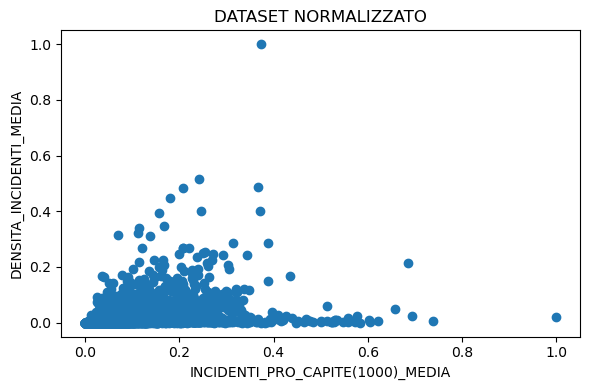

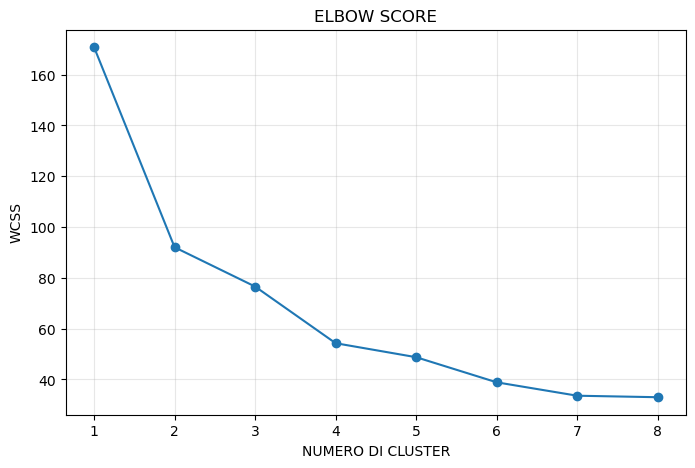

k = 2 -> Silhouette Score = 0.426
k = 3 -> Silhouette Score = 0.424
k = 4 -> Silhouette Score = 0.388
k = 5 -> Silhouette Score = 0.364
k = 6 -> Silhouette Score = 0.365
k = 7 -> Silhouette Score = 0.346
k = 8 -> Silhouette Score = 0.299


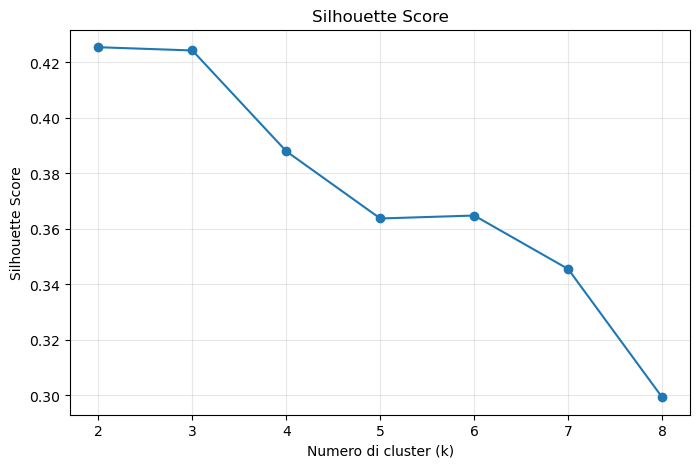

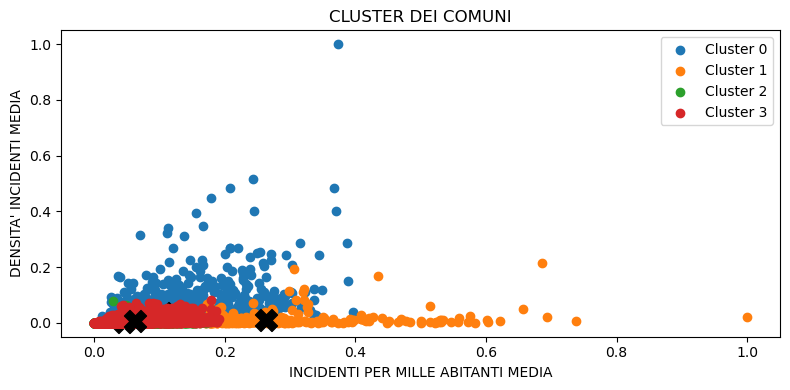

In [471]:
input_dataframe = df_accidents_municipality_agg[["INCIDENTI_PRO_CAPITE(1000)_MEDIA","DENSITA_INCIDENTI_MEDIA","LOG_RESIDENTI"]]

scaler = MinMaxScaler()

scaled_dataframe = pd.DataFrame(scaler.fit_transform(input_dataframe),
                                columns=input_dataframe.columns)

# Visualizzazione del dataset normalizzato
plt.figure(figsize=(6, 4))

plt.scatter(scaled_dataframe["INCIDENTI_PRO_CAPITE(1000)_MEDIA"],
            scaled_dataframe["DENSITA_INCIDENTI_MEDIA"],
            marker="o")

plt.title("DATASET NORMALIZZATO")
plt.xlabel("INCIDENTI_PRO_CAPITE(1000)_MEDIA")
plt.ylabel("DENSITA_INCIDENTI_MEDIA")

plt.tight_layout()

plt.show()


# Metodo del gomito-Elbow score
k_values = range(1, 9)
wcss = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_dataframe)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss,marker="o")
plt.title("ELBOW SCORE")
plt.xlabel("NUMERO DI CLUSTER")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()




k_values = range(2, 9)
scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_dataframe.drop(columns="CLUSTER", errors="ignore"))

    score = silhouette_score(
        scaled_dataframe.drop(columns="CLUSTER", errors="ignore"),
        labels
    )

    scores.append(score)
    print(f"k = {k} -> Silhouette Score = {score:.3f}")



plt.figure(figsize=(8,5))

plt.plot(k_values, scores, marker="o")

plt.title("Silhouette Score")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()


# Più è vicino a 1, meglio è. In questo caso il migliore sembrerebbe k=2


# MODELLO K-MEANS

# Inizializzazione e addestramento del modello
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans.fit(scaled_dataframe)

# Assegnazione dei cluster al DataFrame normalizzato
scaled_dataframe["CLUSTER"] = kmeans.labels_
# Copia dei cluster nel DataFrame originale
df_accidents_municipality_agg["CLUSTER"] = scaled_dataframe["CLUSTER"]


# VISUALIZZAZIONE DEI CLUSTER
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("CLUSTER")

plt.figure(figsize=(8,4))

for cluster, data in clusters:

    plt.scatter(data["INCIDENTI_PRO_CAPITE(1000)_MEDIA"],data["DENSITA_INCIDENTI_MEDIA"],
                label=f"Cluster {cluster}")

    plt.scatter(centroids[cluster, 0],centroids[cluster, 1],marker="X",color="black",
                s=250)

plt.xlabel("INCIDENTI PER MILLE ABITANTI MEDIA")
plt.ylabel("DENSITA' INCIDENTI MEDIA")
plt.title("CLUSTER DEI COMUNI")
plt.legend()

plt.tight_layout()

plt.show()

In [472]:
summary2 = (
    df_accidents_municipality_agg
    .groupby("CLUSTER")
    .agg(
        NUM_COMUNI=("COMUNE","count"),
        INCIDENTI_PRO_CAPITE=("INCIDENTI_PRO_CAPITE(1000)_MEDIA","mean"),
        DENSITA_INCIDENTI=("DENSITA_INCIDENTI_MEDIA","mean"),
        LOG_RESIDENTI=("LOG_RESIDENTI","mean"),
        RESIDENTI_MEDI=("RESIDENTI","mean")
    )
    .round(2)
)

display(summary2)

,NUM_COMUNI,INCIDENTI_PRO_CAPITE,DENSITA_INCIDENTI,LOG_RESIDENTI,RESIDENTI_MEDI
CLUSTER,,,,,
0,1729,2.84,2.25,9.70,26704.46
1,396,6.09,0.71,6.85,1377.04
2,2575,1.07,0.07,6.40,717.50
3,3914,1.46,0.34,8.04,3504.61


In [473]:
df_accidents_municipality_agg["CLUSTER"]= df_accidents_municipality_agg["CLUSTER"].replace({0 : "Grandi comuni urbanizzati",
                                                                                            2: "Piccoli comuni a basso rischio",
                                                                                            3 : "Comuni intermedi a rischio contenuto",
                                                                                            1: "Piccoli comuni ad alto rischio pro capite"})

df_clustering_context=df_accidents_municipality_agg.copy()
df_clustering_context

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE,LOG_SUPERFICIE,LOG_RESIDENTI,CLUSTER
0,1001,Agliè,95,2630.541667,13.146217,1,Piemonte,3.958333,200.098761,0.301101,1.504760,Piccolo,Piccolo,2.649447,7.875325,Comuni intermedi a rischio contenuto
1,1002,Airasca,262,3699.041667,15.739300,1,Piemonte,10.916667,235.019452,0.693593,2.951215,Piccolo,Piccolo,2.817759,8.216099,Comuni intermedi a rischio contenuto
2,1003,Ala di Stura,6,463.875000,46.331517,1,Piemonte,0.250000,10.012083,0.005396,0.538938,Molto piccolo,Piccolo,3.857176,6.141769,Piccoli comuni a basso rischio
3,1004,Albiano d'Ivrea,107,1696.000000,11.732788,1,Piemonte,4.458333,144.552179,0.379989,2.628734,Piccolo,Piccolo,2.544180,7.436617,Comuni intermedi a rischio contenuto
4,1005,Alice Superiore,21,687.222222,7.379600,1,Piemonte,0.875000,93.124590,0.118570,1.273242,Molto piccolo,Molto piccolo,2.125800,6.534112,Piccoli comuni a basso rischio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8609,111103,Villaputzu,48,4529.625000,181.351050,20,Sardegna,2.000000,24.977109,0.011028,0.441538,Piccolo,Grande,5.205934,8.418615,Comuni intermedi a rischio contenuto
8610,111104,Villasalto,18,981.000000,130.359600,20,Sardegna,0.750000,7.525338,0.005753,0.764526,Molto piccolo,Grande,4.877939,6.889591,Piccoli comuni a basso rischio
8611,111105,Villasimius,54,3707.500000,58.074450,20,Sardegna,2.250000,63.840467,0.038743,0.606878,Piccolo,Medio,4.078799,8.218383,Comuni intermedi a rischio contenuto
8612,111106,Villasor,104,6692.125000,86.803600,20,Sardegna,4.333333,77.095017,0.049921,0.647527,Medio,Medio,4.475103,8.808836,Comuni intermedi a rischio contenuto


In [474]:
pd.crosstab(
    df_clustering_risk["CLUSTER"],
    df_clustering_context["CLUSTER"]
)

CLUSTER,Comuni intermedi a rischio contenuto,Grandi comuni urbanizzati,Piccoli comuni a basso rischio,Piccoli comuni ad alto rischio pro capite
CLUSTER,,,,
Alta incidentalità,76,472,14,309
Bassa incidentalità,2359,293,1983,0
Incidentalità critica,0,16,0,79
Media incidentalità,1479,948,578,8


Il confronto tra i due modelli di clustering evidenzia come il secondo approccio, che integra anche la dimensione demografica del comune, non modifichi sostanzialmente l'individuazione dei comuni più critici, ma ne migliori l'interpretazione.

In particolare, gli appartenenti al cluster di "Incidentalità critica" del primo modello vengono quasi interamente suddivisi tra due profili distinti: circa l' 80% appartiene al cluster dei piccoli comuni ad alto rischio pro capite, mentre il restante rientra nel cluster dei grandi comuni urbanizzati.

Questo risultato suggerisce che livelli di rischio simili possano derivare da contesti territoriali differenti. Nei piccoli comuni il rischio è principalmente riconducibile a un elevato numero di incidenti rapportato alla popolazione residente, mentre nei grandi centri urbani la criticità è maggiormente legata alla forte concentrazione spaziale degli incidenti.

L'introduzione della dimensione demografica nel secondo clustering non sostituisce quindi il modello basato esclusivamente sugli indicatori di incidentalità, ma lo completa, consentendo una caratterizzazione più accurata dei comuni individuati come prioritari.